Configuração inicial

In [48]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None) # Limite de colunas que serão mostradas
pd.set_option("display.max_rows", 100) # Limite de linhas que serão mostradas

plt.rcParams["figure.figsize"] = (10,6) # Tamanho das figuras, largura e altura

Importação da base

In [49]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC.csv")
print("Base carregada com sucesso.")

Base carregada com sucesso.


Checagem dos valores nulos

In [50]:
df_nulos = df_acre.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
df_nulos = df_nulos.to_frame("Quantidade de nulos")
df_nulos["Porcentagem"] = (df_acre.isnull().sum() / len(df_acre) * 100).sort_values(ascending=False) # Coluna de porcentagem

print(df_nulos)

                        Quantidade de nulos  Porcentagem
SG_UF_ESC                             20077    82.709895
NO_MUNICIPIO_ESC                      20077    82.709895
TP_SIT_FUNC_ESC                       20077    82.709895
TP_DEPENDENCIA_ADM_ESC                20077    82.709895
TP_LOCALIZACAO_ESC                    20077    82.709895
CO_MUNICIPIO_ESC                      20077    82.709895
CO_UF_ESC                             20077    82.709895
TP_ENSINO                             17746    73.107028
NU_NOTA_CN                             9120    37.571064
NU_NOTA_MT                             9120    37.571064
CO_PROVA_MT                            9120    37.571064
CO_PROVA_CN                            9120    37.571064
NU_NOTA_COMP3                          8112    33.418472
CO_PROVA_CH                            8112    33.418472
NU_NOTA_CH                             8112    33.418472
NU_NOTA_LC                             8112    33.418472
CO_PROVA_LC                    

# Análise dos dados envolvendo escola

## Mapeamento das colunas de escolas

In [51]:
df_escolas = df_acre.dropna(subset=['TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC']).copy()

# Filtra apenas escolas Públicas (2) e Privadas (3)
df_escolas = df_acre[df_acre['TP_ESCOLA'].isin([2, 3])].copy()
mapeamento_localizacao = {1: 'Urbana', 2: 'Rural'}
mapeamento_tp_escola = {2: "Pública", 3: "Privada"}
df_escolas['LOCALIZACAO_ESC'] = df_escolas['TP_LOCALIZACAO_ESC'].map(mapeamento_localizacao)
df_escolas['TP_ESCOLA'] = df_escolas['TP_ESCOLA'].map(mapeamento_tp_escola)

Preenchimento de notas vazias pela mediana

In [52]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

for coluna_nota in colunas_notas:
    df_escolas[coluna_nota] = df_escolas[coluna_nota].fillna(df_escolas[coluna_nota].median())

Configuração da coluna de notas

In [53]:
df_escolas['MEDIA_GERAL'] = df_escolas[colunas_notas].mean(axis=1)

Comparação entre alunos de escola pública e alunos de escola privada (Média):


In [54]:
comparativo_adm = df_escolas.groupby('TP_ESCOLA')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_adm)

,TP_ESCOLA,MEDIA_GERAL
0,Privada,610.089907
1,Pública,498.371427


Comparação entre alunos de escola em zona rural e zona urbana

In [55]:
comparativo_localizacao = df_escolas.groupby('LOCALIZACAO_ESC')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_localizacao)

,LOCALIZACAO_ESC,MEDIA_GERAL
0,Rural,491.792638
1,Urbana,513.613324


Dados nulos nesse dataframe

In [56]:
df_nulos_escola = df_escolas.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
print(df_nulos_escola)

TP_SIT_FUNC_ESC           2770
SG_UF_ESC                 2770
CO_MUNICIPIO_ESC          2770
TP_DEPENDENCIA_ADM_ESC    2770
NO_MUNICIPIO_ESC          2770
CO_UF_ESC                 2770
TP_LOCALIZACAO_ESC        2770
LOCALIZACAO_ESC           2770
CO_PROVA_MT               1932
CO_PROVA_CN               1932
CO_PROVA_CH               1640
NU_NOTA_COMP3             1640
NU_NOTA_COMP5             1640
NU_NOTA_COMP2             1640
CO_PROVA_LC               1640
TP_STATUS_REDACAO         1640
NU_NOTA_COMP4             1640
NU_NOTA_COMP1             1640
TP_ENSINO                  439
TP_ESTADO_CIVIL              0
TP_SEXO                      0
TP_FAIXA_ETARIA              0
TP_COR_RACA                  0
CO_UF_PROVA                  0
CO_MUNICIPIO_PROVA           0
TP_PRESENCA_LC               0
SG_UF_PROVA                  0
TP_PRESENCA_MT               0
TP_PRESENCA_CN               0
TP_PRESENCA_CH               0
TP_NACIONALIDADE             0
TP_ANO_CONCLUIU              0
TP_ST_CO

Verificação dos outliers

In [57]:
Q1 = df_escolas["MEDIA_GERAL"].quantile(0.25)
Q3 = df_escolas["MEDIA_GERAL"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

outliers = df_escolas[(df_escolas["MEDIA_GERAL"] < lower) | (df_escolas['MEDIA_GERAL'] > upper)]
print("Outliers em MEDIA_GERAL utilizando IQR:")
print(outliers["MEDIA_GERAL"])


Outliers em MEDIA_GERAL utilizando IQR:
22       724.98
37       674.08
68       666.04
89       321.52
97       340.52
          ...  
23413    314.04
23554    300.86
23561    302.96
23597    325.54
24151    340.42
Name: MEDIA_GERAL, Length: 401, dtype: float64


Gráficos do dataframe de escolas


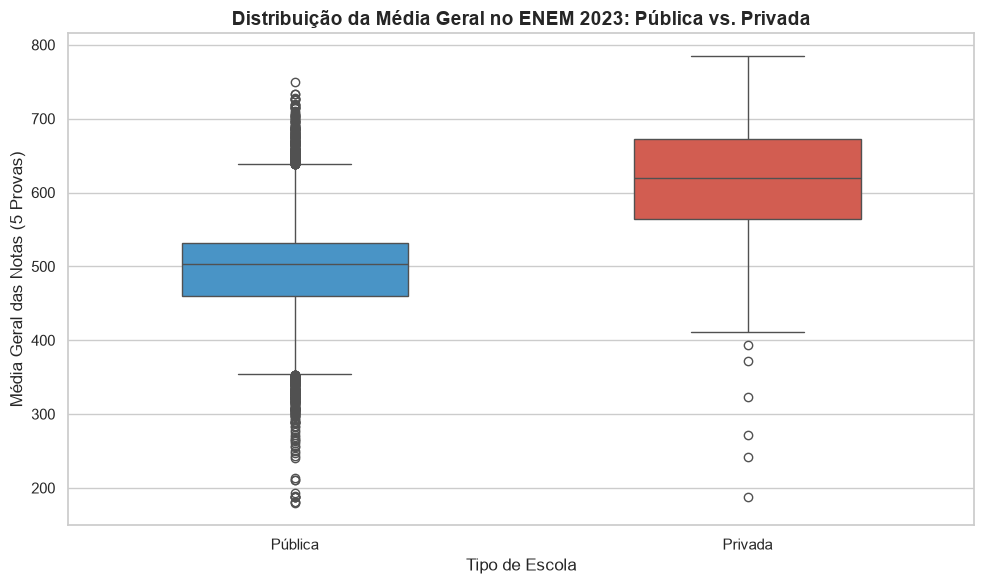

In [58]:
sns.boxplot(
    x='TP_ESCOLA', 
    y='MEDIA_GERAL', 
    data=df_escolas, 
    palette={'Pública': '#3498db', 'Privada': '#e74c3c'}, # Cores contrastantes
    hue='TP_ESCOLA',
    width=0.5
)

plt.title('Distribuição da Média Geral no ENEM 2023: Pública vs. Privada', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral das Notas (5 Provas)')
plt.tight_layout()
plt.show()


# Mapeamento de colunas do questionário socioeconômico

In [59]:
# Colunas respectivamente: Escolaridade do pai, escolaridade da mãe, renda, celular, computador e internet.
# ["Q001", "Q002", "Q006","Q022","Q024","Q025"]

mapeamento_escolaridade = {
    'A': 1,
    'B': 2,
    'C': 2,
    'D': 3,
    'E' : 4,
    'F' : 5,
    'G' : 5,
}

labels_escolaridade = {
    1: 'Nunca estudou',
    2: 'Fundamental incompleto',
    3: 'Fundamental completo',
    4: 'Ensino médio completo',
    5: 'Superior completo',
}

ordem_labels = [labels_escolaridade[i] for i in labels_escolaridade]

df_questionario = df_acre.copy()


df_questionario["Q001"] = df_acre["Q001"].map(mapeamento_escolaridade)
df_questionario["Q002"] = df_acre["Q002"].map(mapeamento_escolaridade)



Análise da correlação entre escolaridade do responsável e nota média do candidato

In [60]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_questionario['MEDIA_GERAL'] = df_questionario[colunas_notas].mean(axis=1)

analise_mae = df_questionario.groupby('Q001')['MEDIA_GERAL'].mean().reset_index()
display(analise_mae)

,Q001,MEDIA_GERAL
0,1.0,468.566669
1,2.0,486.679404
2,3.0,502.960069
3,4.0,519.489046
4,5.0,560.258615


In [61]:
analise_pai = df_questionario.groupby('Q002')['MEDIA_GERAL'].mean().reset_index()
display(analise_pai)

,Q002,MEDIA_GERAL
0,1.0,459.188216
1,2.0,479.427598
2,3.0,492.810207
3,4.0,510.339688
4,5.0,550.033360


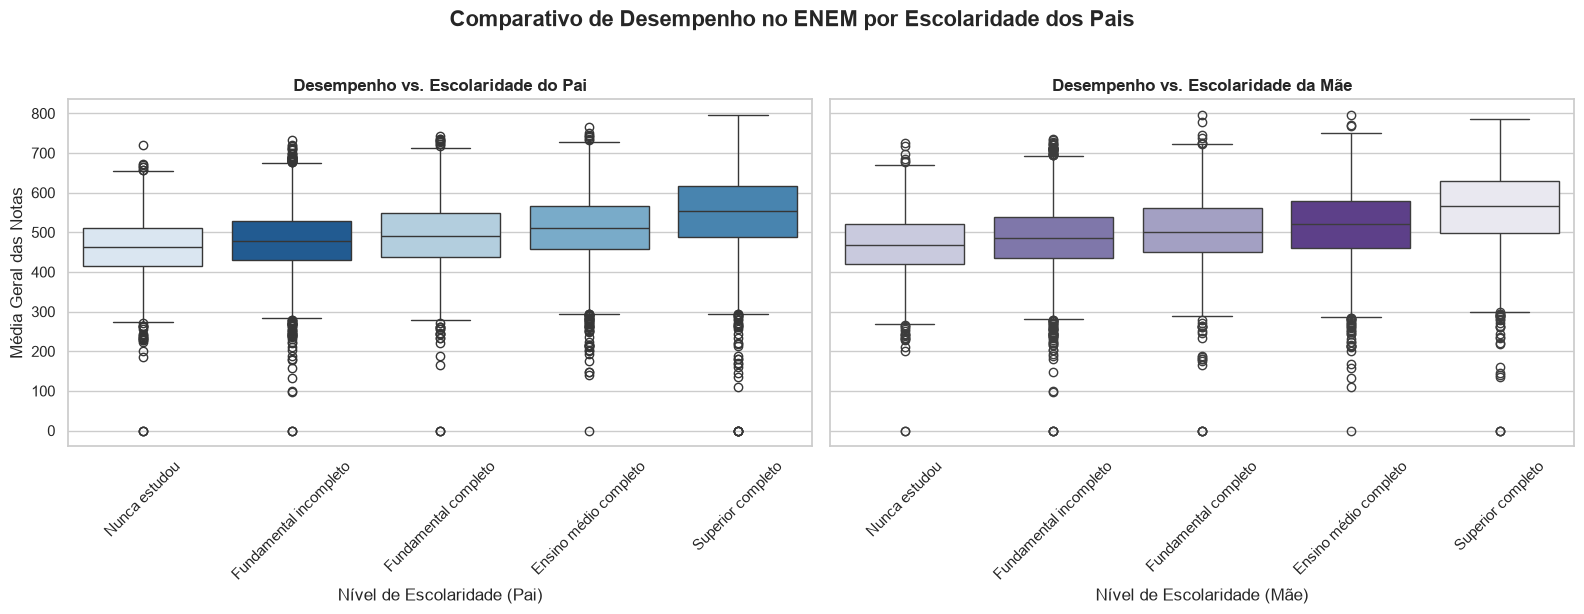

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

df_questionario['ROTULO_MAE'] = df_questionario['Q001'].map(labels_escolaridade)
df_questionario['ROTULO_PAI'] = df_questionario['Q002'].map(labels_escolaridade)


sns.boxplot(
    ax=axes[0],
    x='ROTULO_PAI',
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,
    palette='Blues_r',
    hue='ROTULO_PAI',
    legend=False
)
axes[0].set_title('Desempenho vs. Escolaridade do Pai', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nível de Escolaridade (Pai)')
axes[0].set_ylabel('Média Geral das Notas')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(
    ax=axes[1],
    x='ROTULO_MAE',
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,
    palette='Purples_r',
    hue='ROTULO_MAE',
    legend=False
)
axes[1].set_title('Desempenho vs. Escolaridade da Mãe', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nível de Escolaridade (Mãe)')
axes[1].set_ylabel('')  # Oculta o label do Y pois é compartilhado
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Comparativo de Desempenho no ENEM por Escolaridade dos Pais', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Mapeamento de renda familiar do candidato

In [63]:
mapeamento_renda = {
    'A': 1,
    'B': 2,
    'C': 3, 'D': 3,
    'E': 4, 'F': 4, 'G': 4,
    'H': 5, 'I': 5, 'J': 5, 'K': 5,
    'L': 6, 'M': 6, 'N': 6, 'O': 6, 'P': 6,
    'Q': 7
}

labels_renda = {
    1: 'Sem renda',
    2: 'Até 1 SM (Até R$ 1.320)',
    3: '1 a 2 SM (Até R$ 2.640)',
    4: '2 a 4 SM (Até R$ 5.280)',
    5: '4 a 8 SM (Até R$ 10.560)',
    6: '8 a 20 SM (Até R$ 26.400)',
    7: 'Mais de 20 SM (Mais de R$ 26.400)'
}